In [1]:
import pandas as pd
from graphviz import Digraph

In [2]:
mindmap = pd.read_csv("mindmap.csv")
mindmap.head()

,ID,Layer,Node,Support
0,Z,0,Spark RDD,RDD编程综合实例
1,A,1,创建RDD,运行实例
2,B,1,RDD转换操作,无
3,A1,2,分布式文件创建,无
4,A2,2,本地文件创建,Python文件操作


In [3]:
layer0 = mindmap.query("Layer == 0")
layer1 = mindmap.query("Layer == 1").reset_index(drop=True)
layer2 = mindmap.query("Layer == 2").reset_index(drop=True)
layer2

,ID,Layer,Node,Support
0,A1,2,分布式文件创建,无
1,A2,2,本地文件创建,Python文件操作
2,A3,2,并行集合（列表）创建,Python列表
3,B1,2,Filter,Filter实例
4,B2,2,Map,Map实例
5,B3,2,Flatmap,Flatmap实例
6,B4,2,groupbykey,groupbykey实例
7,B5,2,reducebykey,reducebykey实例


In [4]:
def add_support(graph, item):
    if item.Support == "无":
        return
    shape = "note" if item.Support.endswith("实例") else "box"

    graph.node(item.ID + "s", label=item.Support, shape=shape)
    graph.edge(
        item.ID,
        item.ID + "s",
        label="支持",
        constraint="true",
        arrowhead="none",
        arrowtail="normal",
        dir="both",
    )

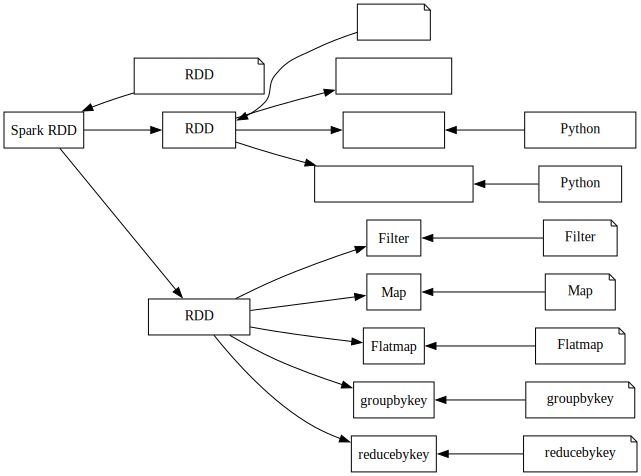

In [5]:
graph = Digraph()
graph.node(layer0.iloc[0].ID, layer0.iloc[0].Node, shape="box")
add_support(graph, layer0.iloc[0])

for i in range(layer1.shape[0]):
    item = layer1.iloc[i]
    graph.node(item.ID, item.Node, shape="box")
    graph.edge(layer0.iloc[0].ID, item.ID, label="包含")
    add_support(graph, item)
    layer2d = layer2[layer2.ID.str.startswith(item.ID)].reset_index(drop=True)
    for j in range(layer2d.shape[0]):
        item2 = layer2d.iloc[j]
        node2 = graph.node(item2.ID, label=item2.Node, shape="box")
        edge2 = graph.edge(item.ID, item2.ID, label="包含")
        add_support(graph, item2)


# graph.attr(layout="twopi", ranksep="2", normalize="1")
graph.attr(rankdir="LR", ranksep="0.3", normalize="1")
graph

In [7]:
# graph.format = "svg"
# graph.render("dot")